In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats

# ── Project Paths ──────────────────────────────────────────────────
CLEAN_DIR = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Hypothesis 3 - Religion\Datasets\Clean Data"
CHART_DIR_H3 = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO\Hypothesis 3"
PEW_FILE = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Hypothesis 3 - Religion\Datasets\Religious-Composition-2010-2020-dataset\Religious Composition 2010-2020 dataset\Religious Composition 2010-2020 (percentages).csv"
# ── Load cleaned WHO dataframe ─────────────────────────────────────
who = pd.read_csv(os.path.join(CLEAN_DIR, "who_merged_clean.csv"))

# ── Load Pew religious composition data ───────────────────────────
pew_raw = pd.read_csv(PEW_FILE)

# ── Filter Pew to 2010 snapshot ────────────────────────────────────
pew = pew_raw[pew_raw['Year'] == 2010].copy()

# ── Derive Religious Prevalence ────────────────────────────────────
pew['Religious_Prevalence'] = 100 - pew['Religiously_unaffiliated']

# ── Confirm ────────────────────────────────────────────────────────
print("WHO shape:", who.shape)
print("Pew shape:", pew.shape)
print("\nPew columns:", pew.columns.tolist())
print("\nPew sample:")
pew[['Country', 'Religiously_unaffiliated', 'Religious_Prevalence']].head(10)

WHO shape: (2938, 25)
Pew shape: (208, 14)

Pew columns: ['Region', 'Country', 'Year', 'Population', 'Christians', 'Muslims', 'Religiously_unaffiliated', 'Buddhists', 'Hindus', 'Jews', 'Other_religions', 'Level', 'Countrycode', 'Religious_Prevalence']

Pew sample:


,Country,Religiously_unaffiliated,Religious_Prevalence
0,All World,23.292166,76.707834
2,All Asia-Pacific,33.019299,66.980701
4,All Europe,18.705446,81.294554
6,All Latin America-Caribbean,7.840712,92.159288
8,All Middle East-North Africa,0.370202,99.629798
10,All North America,17.187750,82.812250
12,All Sub-Saharan Africa,3.087237,96.912763
14,Afghanistan,0.008652,99.991348
16,Albania,9.537429,90.462571
18,Algeria,1.084724,98.915276


In [2]:
# ── Drop regional aggregate rows ───────────────────────────────────
pew = pew[~pew['Country'].str.startswith('All')].copy()

# ── Confirm ────────────────────────────────────────────────────────
print("Pew shape after dropping aggregates:", pew.shape)
print("First few countries:")
pew[['Country', 'Religious_Prevalence']].head(10)

Pew shape after dropping aggregates: (201, 14)
First few countries:


,Country,Religious_Prevalence
14,Afghanistan,99.991348
16,Albania,90.462571
18,Algeria,98.915276
20,Angola,95.523150
22,Argentina,90.272491
24,Armenia,98.793858
26,Aruba,94.387748
28,Australia,75.141317
30,Austria,86.494733
32,Azerbaijan,98.931604


In [9]:
# ── Merge Pew onto WHO ─────────────────────────────────────────────
who_religion = pd.merge(
    who,
    pew[['Country', 'Religious_Prevalence']],
    on='Country',
    how='left'
)

# ── Confirm ────────────────────────────────────────────────────────
print("Merged shape:", who_religion.shape)
print("Missing Religious_Prevalence:", who_religion['Religious_Prevalence'].isnull().sum())
print("\nCountries with no Pew match:")
no_match = who_religion[who_religion['Religious_Prevalence'].isnull()]['Country'].unique()
print(no_match)

Merged shape: (2938, 26)
Missing Religious_Prevalence: 58

Countries with no Pew match:
['Antigua and Barbuda' 'Cook Islands' 'Dominica' 'Marshall Islands'
 'Monaco' 'Nauru' 'Niue' 'Palau' 'Saint Kitts and Nevis' 'Saint Lucia'
 'Saint Vincent and the Grenadines' 'San Marino' 'Tuvalu']


In [4]:
# ── Rename Pew countries to match WHO/World Bank naming ────────────
pew['Country'] = pew['Country'].replace({
    'Bahamas'                  : 'Bahamas, The',
    'Bosnia-Herzegovina'       : 'Bosnia and Herzegovina',
    'Brunei'                   : 'Brunei Darussalam',
    'Cape Verde'               : 'Cabo Verde',
    'Congo, Dem. Rep.'         : 'Congo, Dem. Rep.',
    'Congo, Rep.'              : 'Congo, Rep.',
    "Côte d'Ivoire"            : "Cote d'Ivoire",
    'Czech Republic'           : 'Czechia',
    'Egypt'                    : 'Egypt, Arab Rep.',
    'Gambia'                   : 'Gambia, The',
    'Iran'                     : 'Iran, Islamic Rep.',
    'Kyrgyzstan'               : 'Kyrgyz Republic',
    'Laos'                     : 'Lao PDR',
    'Micronesia'               : 'Micronesia, Fed. Sts.',
    'North Korea'              : "Korea, Dem. People's Rep.",
    'Russia'                   : 'Russian Federation',
    'Slovakia'                 : 'Slovak Republic',
    'South Korea'              : 'Korea, Rep.',
    'Syria'                    : 'Syrian Arab Republic',
    'Turkey'                   : 'Turkiye',
    'Venezuela'                : 'Venezuela, RB',
    'Vietnam'                  : 'Viet Nam',
    'Yemen'                    : 'Yemen, Rep.',
    'Republic of the Congo'                : 'Congo, Rep.',
    'Democratic Republic of the Congo'     : 'Congo, Dem. Rep.',
    'Federated States of Micronesia'       : 'Micronesia, Fed. Sts.',
    'Ivory Coast'                          : "Cote d'Ivoire",
    'Republic of the Congo'            : 'Congo, Rep.',
    'Democratic Republic of the Congo' : 'Congo, Dem. Rep.',
    'Federated States of Micronesia'   : 'Micronesia, Fed. Sts.',
    "Côte d'Ivoire"                    : "Cote d'Ivoire",
})

print("Rename complete.")

Rename complete.


In [5]:
# ── Check if remaining unmatched countries exist in Pew at all ─────
unmatched = ['Antigua and Barbuda', "Cote d'Ivoire", 'Congo, Rep.', 
             'Cook Islands', 'Congo, Dem. Rep.', 'Dominica', 
             'Marshall Islands', 'Micronesia, Fed. Sts.', 'Monaco', 
             'Nauru', 'Niue', 'Palau', 'Saint Kitts and Nevis', 
             'Saint Lucia', 'Saint Vincent and the Grenadines', 
             'San Marino', 'Tuvalu']

print("Searching Pew for these countries...")
for country in unmatched:
    match = pew_raw[pew_raw['Country'].str.contains(country.split(',')[0], case=False)]
    if len(match) > 0:
        print(f"FOUND: {country} → {match['Country'].values}")
    else:
        print(f"NOT IN PEW: {country}")

Searching Pew for these countries...
NOT IN PEW: Antigua and Barbuda
NOT IN PEW: Cote d'Ivoire
FOUND: Congo, Rep. → ['Democratic Republic of the Congo' 'Democratic Republic of the Congo'
 'Republic of the Congo' 'Republic of the Congo']
NOT IN PEW: Cook Islands
FOUND: Congo, Dem. Rep. → ['Democratic Republic of the Congo' 'Democratic Republic of the Congo'
 'Republic of the Congo' 'Republic of the Congo']
FOUND: Dominica → ['Dominican Republic' 'Dominican Republic']
NOT IN PEW: Marshall Islands
FOUND: Micronesia, Fed. Sts. → ['Federated States of Micronesia' 'Federated States of Micronesia']
NOT IN PEW: Monaco
NOT IN PEW: Nauru
NOT IN PEW: Niue
NOT IN PEW: Palau
NOT IN PEW: Saint Kitts and Nevis
NOT IN PEW: Saint Lucia
NOT IN PEW: Saint Vincent and the Grenadines
NOT IN PEW: San Marino
NOT IN PEW: Tuvalu


In [10]:
# ── Save merged dataframe ──────────────────────────────────────────
who_religion.to_csv(os.path.join(CLEAN_DIR, "who_religion_merged.csv"), index=False)
print("Saved successfully.")
print("Shape:", who_religion.shape)

Saved successfully.
Shape: (2938, 26)


In [7]:
print("WHO shape:", who.shape)
print("Pew shape:", pew.shape)
print("Merged shape:", who_religion.shape)
print("Missing Religious_Prevalence:", who_religion['Religious_Prevalence'].isnull().sum())
print("\nCLEAN_DIR:", CLEAN_DIR)

WHO shape: (2938, 25)
Pew shape: (201, 14)
Merged shape: (2938, 26)
Missing Religious_Prevalence: 426

CLEAN_DIR: C:\Data Science\DS Projects\Health vs Wealth analysis\Hypothesis 3 - Religion\Datasets\Clean Data


In [8]:
# ── Rename Pew countries to match WHO/World Bank naming ────────────
pew['Country'] = pew['Country'].replace({
    'Bahamas'                          : 'Bahamas, The',
    'Bosnia-Herzegovina'               : 'Bosnia and Herzegovina',
    'Brunei'                           : 'Brunei Darussalam',
    'Cape Verde'                       : 'Cabo Verde',
    "Côte d'Ivoire"                    : "Cote d'Ivoire",
    'Czech Republic'                   : 'Czechia',
    'Egypt'                            : 'Egypt, Arab Rep.',
    'Gambia'                           : 'Gambia, The',
    'Iran'                             : 'Iran, Islamic Rep.',
    'Kyrgyzstan'                       : 'Kyrgyz Republic',
    'Laos'                             : 'Lao PDR',
    'Micronesia'                       : 'Micronesia, Fed. Sts.',
    'North Korea'                      : "Korea, Dem. People's Rep.",
    'Republic of the Congo'            : 'Congo, Rep.',
    'Democratic Republic of the Congo' : 'Congo, Dem. Rep.',
    'Federated States of Micronesia'   : 'Micronesia, Fed. Sts.',
    'Russia'                           : 'Russian Federation',
    'Slovakia'                         : 'Slovak Republic',
    'South Korea'                      : 'Korea, Rep.',
    'Syria'                            : 'Syrian Arab Republic',
    'Turkey'                           : 'Turkiye',
    'Venezuela'                        : 'Venezuela, RB',
    'Vietnam'                          : 'Viet Nam',
    'Yemen'                            : 'Yemen, Rep.',
})

print("Rename complete.")

Rename complete.


In [11]:
print("WHO shape:", who.shape)
print("Pew shape:", pew.shape)
print("Merged shape:", who_religion.shape)
print("Missing Religious_Prevalence:", who_religion['Religious_Prevalence'].isnull().sum())
print("\nCLEAN_DIR:", CLEAN_DIR)

WHO shape: (2938, 25)
Pew shape: (201, 14)
Merged shape: (2938, 26)
Missing Religious_Prevalence: 58

CLEAN_DIR: C:\Data Science\DS Projects\Health vs Wealth analysis\Hypothesis 3 - Religion\Datasets\Clean Data


In [12]:
# ── Religious Prevalence distribution ──────────────────────────────
who_religion_country = who_religion.drop_duplicates(subset='Country')[
    ['Country', 'Region', 'Religious_Prevalence']
].dropna().sort_values('Religious_Prevalence')

print("Count:", len(who_religion_country))
print("\nDistribution:")
print(who_religion_country['Religious_Prevalence'].describe())

print("\nLowest 10:")
print(who_religion_country.head(10))

print("\nHighest 10:")
print(who_religion_country.tail(10))

Count: 180

Distribution:
count    180.000000
mean      91.176656
std       14.242873
min       12.577995
25%       87.542767
50%       97.399638
75%       99.726030
max      100.000000
Name: Religious_Prevalence, dtype: float64

Lowest 10:
                        Country                 Region  Religious_Prevalence
560                       China      South & East Asia             12.577995
705   Korea, Dem. People's Rep.      South & East Asia             27.147552
689                     Czechia  Europe & Central Asia             31.462318
2874                   Viet Nam      South & East Asia             37.855167
1314                      Japan      South & East Asia             47.820057
1829                Netherlands  Europe & Central Asia             54.458359
1845                New Zealand                Oceania             55.819286
2087                Korea, Rep.      South & East Asia             58.660522
1716                   Mongolia      South & East Asia            

In [13]:
# ── Preview tier distribution ──────────────────────────────────────
bins = [0, 70, 95, 100]
labels = ['Low', 'Medium', 'High']

who_religion_country['Religiosity_Tier'] = pd.cut(
    who_religion_country['Religious_Prevalence'],
    bins=bins,
    labels=labels
)

print(who_religion_country['Religiosity_Tier'].value_counts().sort_index())
print("\nLow tier countries:")
print(who_religion_country[who_religion_country['Religiosity_Tier'] == 'Low'][['Country', 'Religious_Prevalence']])

Religiosity_Tier
Low        14
Medium     58
High      108
Name: count, dtype: int64

Low tier countries:
                        Country  Religious_Prevalence
560                       China             12.577995
705   Korea, Dem. People's Rep.             27.147552
689                     Czechia             31.462318
2874                   Viet Nam             37.855167
1314                      Japan             47.820057
1829                Netherlands             54.458359
1845                New Zealand             55.819286
2087                Korea, Rep.             58.660522
1716                   Mongolia             62.554344
2810                    Uruguay             63.736210
930                      France             65.517788
240                     Belgium             67.987377
994                     Germany             68.184052
866                     Estonia             68.493000


In [14]:
# ── Apply tiers to full merged dataframe ───────────────────────────
bins = [0, 70, 95, 100]
labels = ['Low', 'Medium', 'High']

who_religion['Religiosity_Tier'] = pd.cut(
    who_religion['Religious_Prevalence'],
    bins=bins,
    labels=labels
)

print("Tier distribution in full dataframe:")
print(who_religion['Religiosity_Tier'].value_counts().sort_index())
print("\nMissing tiers:", who_religion['Religiosity_Tier'].isnull().sum())

Tier distribution in full dataframe:
Religiosity_Tier
Low        224
Medium     928
High      1728
Name: count, dtype: int64

Missing tiers: 58


Low: n=208, r=0.040, R²=0.002, p=0.5622, slope=0.349
Medium: n=928, r=-0.067, R²=0.005, p=0.0398, slope=-0.775
High: n=1700, r=-0.259, R²=0.067, p=0.0000, slope=-3.105


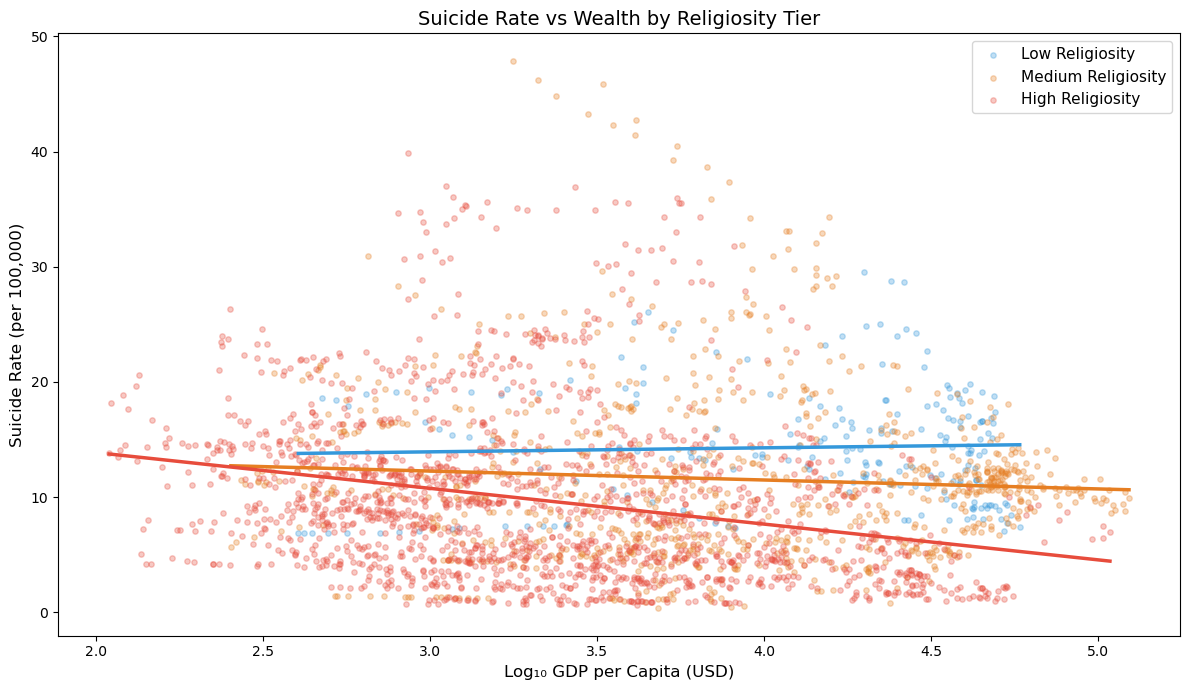

Chart saved.


In [15]:
# ── H3 Main Chart: Suicide Rate vs log(GDP) by Religiosity Tier ────
fig, ax = plt.subplots(figsize=(12, 7))

tier_colors = {
    'Low'    : '#3498db',
    'Medium' : '#e67e22',
    'High'   : '#e74c3c'
}

for tier in ['Low', 'Medium', 'High']:
    subset = who_religion[
        (who_religion['Religiosity_Tier'] == tier) &
        (who_religion['GDP_per_capita'] > 0) &
        (who_religion['Suicide_Rate'].notna())
    ].copy()
    
    subset['log_GDP'] = np.log10(subset['GDP_per_capita'])
    
    ax.scatter(
        subset['log_GDP'],
        subset['Suicide_Rate'],
        color=tier_colors[tier],
        alpha=0.3,
        s=15,
        label=f'{tier} Religiosity'
    )
    
    slope, intercept, r, p, se = stats.linregress(
        subset['log_GDP'], subset['Suicide_Rate']
    )
    x_line = np.linspace(subset['log_GDP'].min(), subset['log_GDP'].max(), 100)
    ax.plot(x_line, intercept + slope * x_line,
            color=tier_colors[tier], linewidth=2.5)
    
    print(f"{tier}: n={len(subset)}, r={r:.3f}, R²={r**2:.3f}, p={p:.4f}, slope={slope:.3f}")

ax.set_xlabel("Log₁₀ GDP per Capita (USD)", fontsize=12)
ax.set_ylabel("Suicide Rate (per 100,000)", fontsize=12)
ax.set_title("Suicide Rate vs Wealth by Religiosity Tier", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR_H3, "H3_Suicide_vs_GDP_by_Religiosity_Tier.png")
plt.savefig(chart_path, dpi=150)
plt.show()
print("Chart saved.")

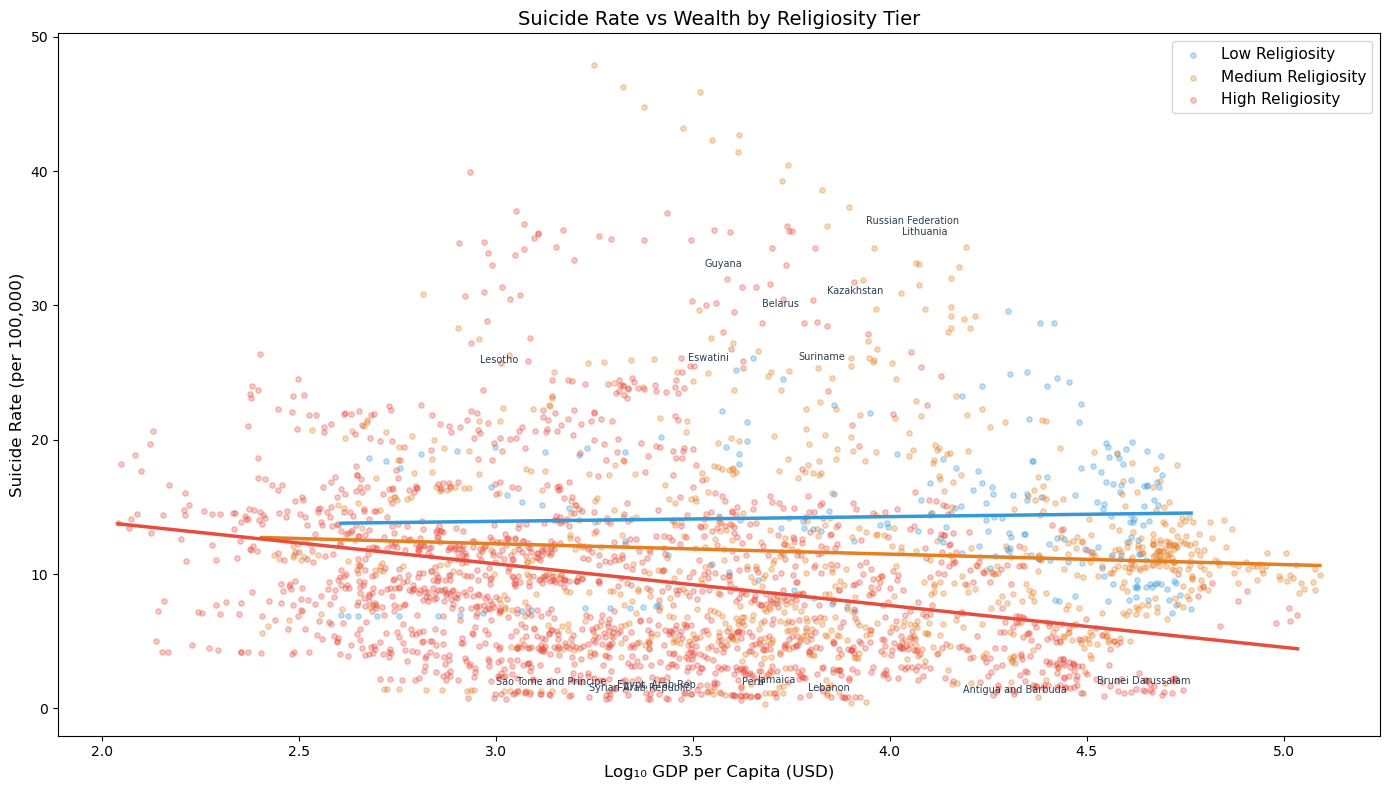

Chart saved.


In [16]:
# ── H3 Main Chart with Outlier Labels ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

tier_colors = {
    'Low'    : '#3498db',
    'Medium' : '#e67e22',
    'High'   : '#e74c3c'
}

# ── Plot by tier ───────────────────────────────────────────────────
for tier in ['Low', 'Medium', 'High']:
    subset = who_religion[
        (who_religion['Religiosity_Tier'] == tier) &
        (who_religion['GDP_per_capita'] > 0) &
        (who_religion['Suicide_Rate'].notna())
    ].copy()

    subset['log_GDP'] = np.log10(subset['GDP_per_capita'])

    ax.scatter(
        subset['log_GDP'],
        subset['Suicide_Rate'],
        color=tier_colors[tier],
        alpha=0.3,
        s=15,
        label=f'{tier} Religiosity'
    )

    slope, intercept, r, p, se = stats.linregress(
        subset['log_GDP'], subset['Suicide_Rate']
    )
    x_line = np.linspace(subset['log_GDP'].min(), subset['log_GDP'].max(), 100)
    ax.plot(x_line, intercept + slope * x_line,
            color=tier_colors[tier], linewidth=2.5)

# ── Label outliers ─────────────────────────────────────────────────
# Use country-level averages to avoid labeling same country 16 times
country_avg = who_religion[
    (who_religion['GDP_per_capita'] > 0) &
    (who_religion['Suicide_Rate'].notna())
].groupby('Country').agg(
    log_GDP        = ('GDP_per_capita', lambda x: np.log10(x.mean())),
    Suicide_Rate   = ('Suicide_Rate', 'mean'),
    Religiosity_Tier = ('Religiosity_Tier', 'first')
).reset_index()

# Top 8 highest suicide rates
top_suicide = country_avg.nlargest(8, 'Suicide_Rate')
# Bottom 8 lowest suicide rates (non-zero)
low_suicide = country_avg[country_avg['Suicide_Rate'] > 0.5].nsmallest(8, 'Suicide_Rate')

for _, row in pd.concat([top_suicide, low_suicide]).iterrows():
    ax.annotate(
        row['Country'],
        xy=(row['log_GDP'], row['Suicide_Rate']),
        fontsize=7,
        xytext=(4, 4),
        textcoords='offset points',
        color='#2c3e50'
    )

ax.set_xlabel("Log₁₀ GDP per Capita (USD)", fontsize=12)
ax.set_ylabel("Suicide Rate (per 100,000)", fontsize=12)
ax.set_title("Suicide Rate vs Wealth by Religiosity Tier", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR_H3, "H3_Suicide_vs_GDP_by_Religiosity_Tier_labeled.png")
plt.savefig(chart_path, dpi=150)
plt.show()
print("Chart saved.")

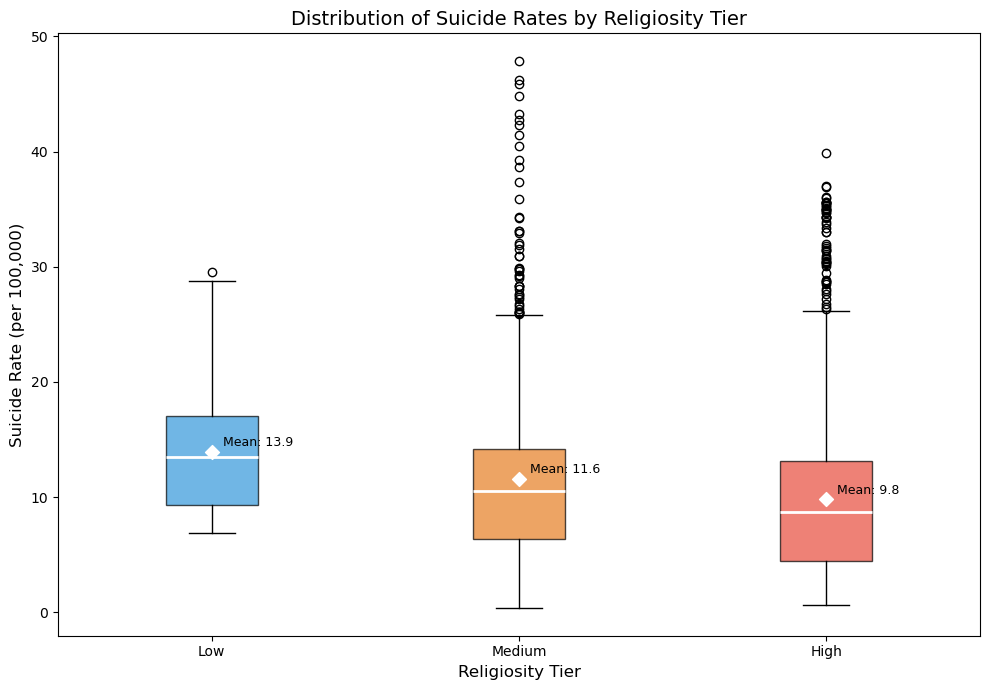

Chart saved.


In [17]:
# ── Box plot: Suicide Rate by Religiosity Tier ─────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

tier_order = ['Low', 'Medium', 'High']
tier_colors = {
    'Low'    : '#3498db',
    'Medium' : '#e67e22',
    'High'   : '#e74c3c'
}

data_by_tier = [
    who_religion[
        (who_religion['Religiosity_Tier'] == tier) &
        (who_religion['Suicide_Rate'].notna())
    ]['Suicide_Rate'].values
    for tier in tier_order
]

bp = ax.boxplot(
    data_by_tier,
    labels=tier_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)

for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.7)

# ── Add mean markers ───────────────────────────────────────────────
for i, (data, tier) in enumerate(zip(data_by_tier, tier_order), start=1):
    mean_val = np.mean(data)
    ax.scatter(i, mean_val, color='white', zorder=5, s=50, marker='D')
    ax.annotate(f'Mean: {mean_val:.1f}', xy=(i, mean_val),
                xytext=(8, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel("Religiosity Tier", fontsize=12)
ax.set_ylabel("Suicide Rate (per 100,000)", fontsize=12)
ax.set_title("Distribution of Suicide Rates by Religiosity Tier", fontsize=14)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR_H3, "H3_Suicide_Boxplot_by_Tier.png")
plt.savefig(chart_path, dpi=150)
plt.show()
print("Chart saved.")